# Phase 2: Unsupervised Learning for Initial Detection (Anomaly-Based IDS)
# Task 2.1: Packet-Level Anomaly Detection
# Autoencoder

Build an unsupervised model that separates benign from non-benign packets.

## Setup, load metadata and sampled packet dataset

In [1]:
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.decomposition import PCA

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"
PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME

with open(META_PATH, "r") as f:
    metadata = json.load(f)

DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH)

BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"
y_true = df[BINARY_COL].map({"benign": 0, "attack": 1}).to_numpy()

print("Dataset shape:", df.shape)
print("\nBinary class counts:")
print(df[BINARY_COL].value_counts())
print("\nTraffic type counts:")
print(df[ATTACK_COL].value_counts())

Dataset shape: (205041, 138)

Binary class counts:
binary_label
benign    200000
attack      5041
Name: count, dtype: int64

Traffic type counts:
attack_type
Benign             200000
DNS Spoofing         3178
DDoS-HTTP Flood       833
Brute Force           404
DoS-HTTP Flood        364
XSS                   262
Name: count, dtype: int64


## Data preprocessing

### Autoencoder feature selection

The autoencoder uses numeric packet behavior, protocol, timing, size, and short-term traffic statistics. Raw IP addresses, MAC addresses, host names, URIs, and user-agent strings are excluded because they are identifiers rather than stable behavior features. A small set of 1, 5, and 30-window statistics is kept, then highly correlated columns are removed using the training set only.

In [2]:
# Basic packet behavior features
base_features = [
    "time_since_previously_displayed_frame",
    "port_class_dst",
    "l4_tcp",
    "l4_udp",
    "ttl",
    "eth_size",
    "tcp_window_size",
    "payload_entropy",
    "payload_length",
    "jitter",
    "dns_len_qry",
    "dns_interval",
    "dns_len_ans",
    "http_content_len",
    "http_response_code",
    "handshake_cipher_suites_length",
    "handshake_extensions_length",
    "handshake_sig_hash_alg_len",
    "icmp_data_size",
    "l3_ip_dst_count",
    "average_p",
    "var_p",
    "iqr_p"
]

# Keep useful short-term and longer-term traffic statistics
rolling_features = []

for group in ["stream", "src_ip", "channel"]:
    rolling_features += [f"{group}_{window}_count" for window in [1, 5, 30]]
    rolling_features += [f"{group}_{window}_{stat}" for window in [5, 30] for stat in ["mean", "var"]]

rolling_features += [
    "stream_jitter_5_mean",
    "stream_jitter_5_var",
    "stream_jitter_30_mean",
    "stream_jitter_30_var"
]

requested_features = base_features + rolling_features
missing_features = [col for col in requested_features if col not in df.columns]
feature_cols = [col for col in requested_features if col in df.columns]
X_raw = df[feature_cols].apply(pd.to_numeric, errors="coerce").copy()

print("Initial selected features:", X_raw.shape[1])
print("Missing requested features:", missing_features)

Initial selected features: 48
Missing requested features: []


### Autoencoder feature engineering

The added features describe protocol usage, payload presence, port behavior, and sudden traffic bursts. These are more useful than raw port numbers and help the autoencoder learn normal packet relationships without using labels.

In [3]:
src_port = pd.to_numeric(df["src_port"], errors="coerce").fillna(-1)
dst_port = pd.to_numeric(df["dst_port"], errors="coerce").fillna(-1)
packet_size = pd.to_numeric(df["eth_size"], errors="coerce").replace(0, np.nan)
payload_size = pd.to_numeric(df["payload_length"], errors="coerce").fillna(0)
dns_query = pd.to_numeric(df["dns_len_qry"], errors="coerce").fillna(0)
dns_answer = pd.to_numeric(df["dns_len_ans"], errors="coerce").fillna(0)
http_length = pd.to_numeric(df["http_content_len"], errors="coerce").fillna(0)
http_code = pd.to_numeric(df["http_response_code"], errors="coerce").fillna(0)
tls_length = pd.to_numeric(df["handshake_extensions_length"], errors="coerce").fillna(0)
icmp_size = pd.to_numeric(df["icmp_data_size"], errors="coerce").fillna(-1)

X_raw["payload_ratio"] = (payload_size / packet_size).clip(0, 1).fillna(0)
X_raw["has_payload"] = (payload_size > 0).astype(int)
X_raw["uses_dns_port"] = ((src_port == 53) | (dst_port == 53)).astype(int)
X_raw["has_dns_data"] = ((dns_query > 0) | (dns_answer > 0)).astype(int)
X_raw["uses_http_port"] = ((src_port == 80) | (dst_port == 80)).astype(int)
X_raw["uses_https_port"] = ((src_port == 443) | (dst_port == 443)).astype(int)
X_raw["has_http_data"] = ((http_length > 0) | (http_code > 0)).astype(int)
X_raw["has_tls_handshake"] = (tls_length > 0).astype(int)
X_raw["is_icmp"] = (icmp_size >= 0).astype(int)
X_raw["src_port_ephemeral"] = (src_port >= 49152).astype(int)
X_raw["dst_port_ephemeral"] = (dst_port >= 49152).astype(int)

def burst_ratio(short_col, long_col):
    short_count = pd.to_numeric(df[short_col], errors="coerce").fillna(0)
    long_count = pd.to_numeric(df[long_col], errors="coerce").fillna(0)
    recent_rate = short_count / 5
    previous_rate = (long_count - short_count).clip(lower=0) / 25
    return (recent_rate + 1) / (previous_rate + 1)

for group in ["stream", "src_ip", "channel"]:
    X_raw[f"{group}_burst_ratio"] = burst_ratio(f"{group}_5_count", f"{group}_30_count")

print("Features after engineering:", X_raw.shape[1])
X_raw.head()

Features after engineering: 62


,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,payload_length,jitter,...,uses_http_port,uses_https_port,has_http_data,has_tls_handshake,is_icmp,src_port_ephemeral,dst_port_ephemeral,stream_burst_ratio,src_ip_burst_ratio,channel_burst_ratio
0,0.000185,1,1,0,64,60,0,0.000000,0,0.000185,...,0,1,0,0,0,0,0,3.800000,1.179039,3.800000
1,0.000290,3,1,0,49,66,65024,0.000000,0,0.000290,...,0,1,0,0,0,0,1,2.800000,1.085714,1.051051
2,0.003855,1,1,0,64,74,14600,0.000000,0,947.623914,...,0,1,0,0,0,1,0,1.200000,1.081081,1.072508
3,0.003104,3,0,1,64,60,0,3.201876,16,0.005255,...,0,0,0,0,0,1,1,2.777778,1.371681,2.826087
4,0.000001,3,1,0,231,66,4415,0.000000,0,0.000001,...,0,1,0,0,0,0,1,1.429706,1.451327,1.429140


### Basic preprocessing

The data is divided into 60% training, 20% validation, and 20% test sets using the same split style as the K-means and Isolation Forest notebooks. Preprocessing is learned from the training set only. Missing rolling variance or jitter values are set to zero because they usually mean that too few earlier packets were available. Other missing values are median-imputed, skewed non-negative features are log-transformed, highly correlated features are removed, and the remaining inputs are standardized for neural-network training. Standardized values are clipped to the range -10 to 10 so a few extreme packets do not dominate the reconstruction loss.

Labels are stored only for validation and final evaluation. They are not passed to the autoencoder or its optimizer during fitting.

In [4]:
# Create 60% training, 20% validation and 20% test sets
all_idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(all_idx, test_size=0.40, random_state=1, stratify=df[ATTACK_COL])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=1, stratify=df.iloc[temp_idx][ATTACK_COL])

# Clean values before learning preprocessing information
X_clean = X_raw.replace([np.inf, -np.inf], np.nan).copy()
zero_fill_cols = [col for col in X_clean.columns if col.endswith("_var") or "jitter" in col]
X_clean[zero_fill_cols] = X_clean[zero_fill_cols].fillna(0)

X_train_df = X_clean.iloc[train_idx].copy()
X_val_df = X_clean.iloc[val_idx].copy()
X_test_df = X_clean.iloc[test_idx].copy()

# Remove unusable columns using training data only
drop_cols = [col for col in X_train_df.columns if X_train_df[col].isna().all() or X_train_df[col].nunique(dropna=True) <= 1]
X_train_df = X_train_df.drop(columns=drop_cols)
X_val_df = X_val_df.drop(columns=drop_cols)
X_test_df = X_test_df.drop(columns=drop_cols)

# Reduce extreme skew without changing binary indicators
log_cols = []
for col in X_train_df.columns:
    values = X_train_df[col].dropna()
    if len(values) > 0 and values.min() >= 0 and values.nunique() > 2 and abs(values.skew()) > 2:
        log_cols.append(col)

for split in [X_train_df, X_val_df, X_test_df]:
    split[log_cols] = np.log1p(split[log_cols].clip(lower=0))

# Remove nearly duplicate features using training correlations only
CORRELATED_FEATURE_THRESHOLD = 0.98
correlation = X_train_df.corr(numeric_only=True).abs()
upper_triangle = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
correlated_cols = [col for col in upper_triangle.columns if (upper_triangle[col] > CORRELATED_FEATURE_THRESHOLD).any()]

X_train_df = X_train_df.drop(columns=correlated_cols)
X_val_df = X_val_df.drop(columns=correlated_cols)
X_test_df = X_test_df.drop(columns=correlated_cols)

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

X_train = preprocess.fit_transform(X_train_df).astype(np.float32)
X_val = preprocess.transform(X_val_df).astype(np.float32)
X_test = preprocess.transform(X_test_df).astype(np.float32)

X_train = np.clip(X_train, -10, 10)
X_val = np.clip(X_val, -10, 10)
X_test = np.clip(X_test, -10, 10)
processed_feature_names = preprocess.named_steps["imputer"].get_feature_names_out(X_train_df.columns)

y_train = y_true[train_idx]
y_val = y_true[val_idx]
y_test = y_true[test_idx]

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("\nPreprocessing summary:")
print("Removed unusable features:", len(drop_cols))
print("Removed correlated features:", len(correlated_cols))
print("Log-transformed features:", len(log_cols))
print("Final model inputs:", len(processed_feature_names))
print("All values finite:", np.isfinite(X_train).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all())
print("\nAttack counts:")
print("Train:", y_train.sum())
print("Validation:", y_val.sum())
print("Test:", y_test.sum())

Training shape: (123024, 61)
Validation shape: (41008, 61)
Test shape: (41009, 61)

Preprocessing summary:
Removed unusable features: 0
Removed correlated features: 6
Log-transformed features: 45
Final model inputs: 61
All values finite: True

Attack counts:
Train: 3024
Validation: 1008
Test: 1009


## Autoencoder model

The model is a small denoising autoencoder. During training, Gaussian noise is added to each input batch, while the clean batch remains the reconstruction target. This discourages the network from learning a simple identity mapping. The encoder compresses the packet features into a low-dimensional bottleneck and the decoder reconstructs the original standardized features.

Packet labels are not used by the model, loss function, optimizer, or early-stopping rule.

In [5]:
torch.set_num_threads(min(4, os.cpu_count() or 1))

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

RANDOM_STATE = 1
BATCH_SIZE = 1024 if len(X_train) >= 1024 else 128


def set_seed(seed=RANDOM_STATE):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class PacketAutoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=8, dropout=0.10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 64), nn.ReLU(), nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


print("Device:", DEVICE)
print("Input features:", X_train.shape[1])
print("Training batch size:", BATCH_SIZE)

Device: mps
Input features: 61
Training batch size: 1024


### Training and reconstruction-error functions

Early stopping uses validation reconstruction loss only. It does not use the validation labels. The anomaly score for one packet is its mean squared reconstruction error across all processed input features.

In [6]:
def make_loader(X, batch_size, shuffle=False):
    data = TensorDataset(torch.from_numpy(X))
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=DEVICE.type == "cuda")


def train_autoencoder(X_train, X_val, bottleneck_dim, dropout=0.10, noise_std=0.05, learning_rate=1e-3, weight_decay=1e-5, max_epochs=25, patience=4):
    set_seed()
    model = PacketAutoencoder(X_train.shape[1], bottleneck_dim, dropout).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    train_loader = make_loader(X_train, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val, BATCH_SIZE)
    history, best_loss, best_state, wait = [], np.inf, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            noisy_batch = batch + noise_std * torch.randn_like(batch)
            optimizer.zero_grad()
            loss = criterion(model(noisy_batch), batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(batch)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)
                val_loss += criterion(model(batch), batch).item() * len(batch)

        train_loss /= len(X_train)
        val_loss /= len(X_val)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_loss - 1e-5:
            best_loss = val_loss
            best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


@torch.no_grad()
def reconstruction_errors(model, X, batch_size=4096):
    model.eval()
    errors = []
    for (batch,) in make_loader(X, batch_size):
        batch = batch.to(DEVICE)
        reconstruction = model(batch)
        errors.append(torch.mean((reconstruction - batch) ** 2, dim=1).cpu().numpy())
    return np.concatenate(errors)

## Tuning

### Tune the bottleneck size

A bottleneck that is too small may lose useful normal-traffic structure, while a large bottleneck may reconstruct attacks too easily. The candidate models below are trained without labels. After training, validation labels are used only to compare the anomaly-score ranking through PR-AUC and ROC-AUC. PR-AUC is the main selection metric because the attack class is highly imbalanced.

In [7]:
bottleneck_values = [4, 6, 8, 10, 12, 14, 16, 20, 30, 40, 45, 50, 55, 60]
tuning_rows = []

for bottleneck_dim in bottleneck_values:
    start_time = time.time()
    model, history = train_autoencoder(X_train, X_val, bottleneck_dim, max_epochs=20)
    val_scores = reconstruction_errors(model, X_val)
    tuning_rows.append({
        "bottleneck_dim": bottleneck_dim,
        "epochs": len(history),
        "val_loss": history["val_loss"].min(),
        "val_pr_auc": average_precision_score(y_val, val_scores),
        "val_roc_auc": roc_auc_score(y_val, val_scores),
        "train_time_sec": time.time() - start_time
    })
    print(f"Bottleneck {bottleneck_dim}: PR-AUC={tuning_rows[-1]['val_pr_auc']:.4f}, epochs={len(history)}")

autoencoder_tuning_df = pd.DataFrame(tuning_rows).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False).reset_index(drop=True)
display(autoencoder_tuning_df.round(4))

Bottleneck 4: PR-AUC=0.1662, epochs=20
Bottleneck 6: PR-AUC=0.1820, epochs=20
Bottleneck 8: PR-AUC=0.1936, epochs=20
Bottleneck 10: PR-AUC=0.1926, epochs=20
Bottleneck 12: PR-AUC=0.1801, epochs=20
Bottleneck 14: PR-AUC=0.1822, epochs=20
Bottleneck 16: PR-AUC=0.1727, epochs=20
Bottleneck 20: PR-AUC=0.2050, epochs=20
Bottleneck 30: PR-AUC=0.1670, epochs=20
Bottleneck 40: PR-AUC=0.1821, epochs=20
Bottleneck 45: PR-AUC=0.1823, epochs=20
Bottleneck 50: PR-AUC=0.2198, epochs=20
Bottleneck 55: PR-AUC=0.1845, epochs=20
Bottleneck 60: PR-AUC=0.1855, epochs=20


,bottleneck_dim,epochs,val_loss,val_pr_auc,val_roc_auc,train_time_sec
0,50,20,0.0611,0.2198,0.8900,12.7621
1,20,20,0.0650,0.2050,0.8750,14.0516
2,8,20,0.0836,0.1936,0.8643,15.1037
3,10,20,0.0742,0.1926,0.8720,13.6624
4,60,20,0.0579,0.1855,0.8820,12.9273
5,55,20,0.0578,0.1845,0.8717,12.8916
6,45,20,0.0590,0.1823,0.8723,14.4552
7,14,20,0.0774,0.1822,0.8694,13.6910
8,40,20,0.0602,0.1821,0.8713,13.9396
9,6,20,0.0962,0.1820,0.8704,13.6264


### Select the best bottleneck

The selected bottleneck is the candidate with the highest validation PR-AUC. The test set is not used for model selection.

In [8]:
best_row = autoencoder_tuning_df.iloc[0]
BEST_BOTTLENECK = int(best_row["bottleneck_dim"])

print("Selected bottleneck size:", BEST_BOTTLENECK)
print("Validation PR-AUC:", round(best_row["val_pr_auc"], 4))
print("Validation ROC-AUC:", round(best_row["val_roc_auc"], 4))

Selected bottleneck size: 50
Validation PR-AUC: 0.2198
Validation ROC-AUC: 0.89


## Training model

### Train the final denoising autoencoder

The final model is retrained from the same training split using the selected bottleneck. Validation reconstruction loss controls early stopping. Labels remain excluded from training.

Training epochs: 30
Best validation loss: 0.052241
Training time (seconds): 19.81


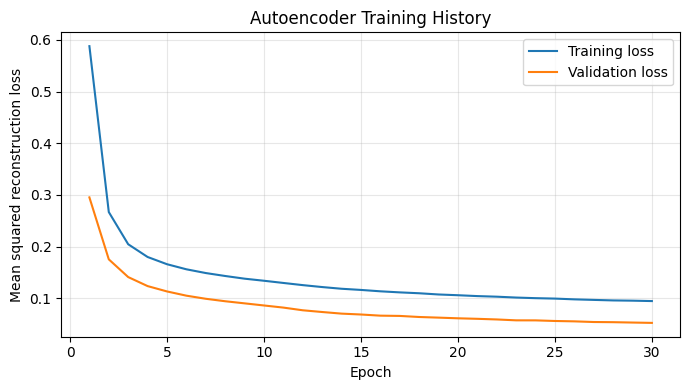

In [9]:
start_train = time.time()
autoencoder, training_history = train_autoencoder(X_train, X_val, BEST_BOTTLENECK, max_epochs=30, patience=5)
train_time = time.time() - start_train

print("Training epochs:", len(training_history))
print("Best validation loss:", round(training_history["val_loss"].min(), 6))
print("Training time (seconds):", round(train_time, 2))

plt.figure(figsize=(7, 4))
plt.plot(training_history["epoch"], training_history["train_loss"], label="Training loss")
plt.plot(training_history["epoch"], training_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared reconstruction loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Generate validation and test anomaly scores

Higher reconstruction error means that the packet is less similar to the traffic patterns learned from the training set. These continuous scores will be used in the next section for threshold sensitivity analysis and final alert generation.

In [10]:
start_score = time.time()
train_scores = reconstruction_errors(autoencoder, X_train)
val_scores = reconstruction_errors(autoencoder, X_val)
test_scores = reconstruction_errors(autoencoder, X_test)
score_time = time.time() - start_score

score_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "mean_score": [train_scores.mean(), val_scores.mean(), test_scores.mean()],
    "median_score": [np.median(train_scores), np.median(val_scores), np.median(test_scores)],
    "max_score": [train_scores.max(), val_scores.max(), test_scores.max()]
})

print("Scoring time (seconds):", round(score_time, 2))
display(score_summary.round(6))

Scoring time (seconds): 0.49


,split,mean_score,median_score,max_score
0,Train,0.052336,0.036927,1.689281
1,Validation,0.052241,0.037036,1.215376
2,Test,0.052010,0.037084,1.258942


## Threshold selection and evaluation

The reconstruction error is a continuous anomaly score. A packet becomes an alert only when its score is greater than or equal to the selected threshold. The threshold is selected using validation data and then applied unchanged to the test set.

### Select alert threshold using the validation set

Several validation alert rates are tested. Among thresholds with a false-positive rate no greater than 1.5%, the threshold with the highest validation F1-score is selected. Labels are used here only to evaluate threshold choices after unsupervised training.

In [11]:
alert_rates = np.arange(0.005, 0.061, 0.005)
threshold_rows = []

for alert_rate in alert_rates:
    threshold = np.quantile(val_scores, 1 - alert_rate)
    val_pred = (val_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, val_pred, labels=[0, 1]).ravel()

    threshold_rows.append({
        "alert_rate": alert_rate,
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "tp": tp,
        "fp": fp,
        "fn": fn
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(4))

MAX_VAL_FPR = 0.015
valid_thresholds = threshold_df[threshold_df["fpr"] <= MAX_VAL_FPR]

if len(valid_thresholds) == 0:
    valid_thresholds = threshold_df.copy()

best_threshold_row = valid_thresholds.sort_values(["f1", "recall"], ascending=False).iloc[0]
FINAL_THRESHOLD = best_threshold_row["threshold"]

print("Selected alert rate:", best_threshold_row["alert_rate"])
print("Selected threshold:", round(FINAL_THRESHOLD, 6))
print("Validation precision:", round(best_threshold_row["precision"], 4))
print("Validation recall:", round(best_threshold_row["recall"], 4))
print("Validation F1:", round(best_threshold_row["f1"], 4))
print("Validation FPR:", round(best_threshold_row["fpr"], 4))

,alert_rate,threshold,precision,recall,f1,fpr,fnr,tp,fp,fn
0,0.005,0.3445,0.3786,0.0774,0.1285,0.0032,0.9226,78,128,930
1,0.010,0.2787,0.3577,0.1458,0.2072,0.0066,0.8542,147,264,861
2,0.015,0.2390,0.3312,0.2024,0.2512,0.0103,0.7976,204,412,804
3,0.020,0.2175,0.3094,0.2520,0.2777,0.0142,0.7480,254,567,754
4,0.025,0.2009,0.2827,0.2877,0.2852,0.0184,0.7123,290,736,718
5,0.030,0.1868,0.2656,0.3244,0.2921,0.0226,0.6756,327,904,681
6,0.035,0.1752,0.2591,0.3690,0.3044,0.0266,0.6310,372,1064,636
7,0.040,0.1667,0.2529,0.4117,0.3133,0.0306,0.5883,415,1226,593
8,0.045,0.1579,0.2416,0.4425,0.3125,0.0350,0.5575,446,1400,562
9,0.050,0.1512,0.2311,0.4702,0.3099,0.0394,0.5298,474,1577,534


Selected alert rate: 0.02
Selected threshold: 0.217474
Validation precision: 0.3094
Validation recall: 0.252
Validation F1: 0.2777
Validation FPR: 0.0142


### Apply the frozen threshold

The selected validation threshold is applied directly to both validation and test reconstruction errors. It is not recalculated using the test labels or test score distribution.

In [12]:
val_pred = (val_scores >= FINAL_THRESHOLD).astype(int)
test_pred = (test_scores >= FINAL_THRESHOLD).astype(int)

df_val_result = df.iloc[val_idx].copy()
df_val_result["model"] = "Autoencoder"
df_val_result["anomaly_score"] = val_scores
df_val_result["y_pred"] = val_pred

df_test_result = df.iloc[test_idx].copy()
df_test_result["model"] = "Autoencoder"
df_test_result["anomaly_score"] = test_scores
df_test_result["y_pred"] = test_pred

print("Validation alerts:", val_pred.sum())
print("Test alerts:", test_pred.sum())

Validation alerts: 821
Test alerts: 826


## Evaluation

### Phase 2 evaluation metrics

The following table reports the required packet-level metrics: accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, false-positive rate, false-negative rate, confusion-matrix counts, alert count, and runtime.

In [13]:
def evaluate_phase2(y_true, y_pred, scores, model_name, runtime_sec):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "alerts": y_pred.sum(),
        "runtime_sec": runtime_sec
    }

    return pd.DataFrame([result])


metrics_df = evaluate_phase2(y_test, test_pred, test_scores, "Autoencoder", train_time + score_time)
display(metrics_df.round(4))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tp,fp,tn,fn,alerts,runtime_sec
0,Autoencoder,0.967,0.2918,0.2389,0.2627,0.8868,0.1997,0.0146,0.7611,241,585,39415,768,826,20.2936


### Validation and test comparison

In [14]:
val_metrics_df = evaluate_phase2(y_val, val_pred, val_scores, "Validation", train_time + score_time)
test_metrics_df = evaluate_phase2(y_test, test_pred, test_scores, "Test", train_time + score_time)

comparison_df = pd.concat([val_metrics_df, test_metrics_df], ignore_index=True)
display(comparison_df[["model", "precision", "recall", "f1", "roc_auc", "pr_auc", "fpr", "fnr", "alerts"]].round(4))

,model,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,alerts
0,Validation,0.3094,0.2520,0.2777,0.8918,0.2172,0.0142,0.7480,821
1,Test,0.2918,0.2389,0.2627,0.8868,0.1997,0.0146,0.7611,826


### Threshold sensitivity analysis

The plot shows how precision, recall, F1-score, and false-positive rate change as the validation alert rate increases. The dashed line marks the selected alert rate.

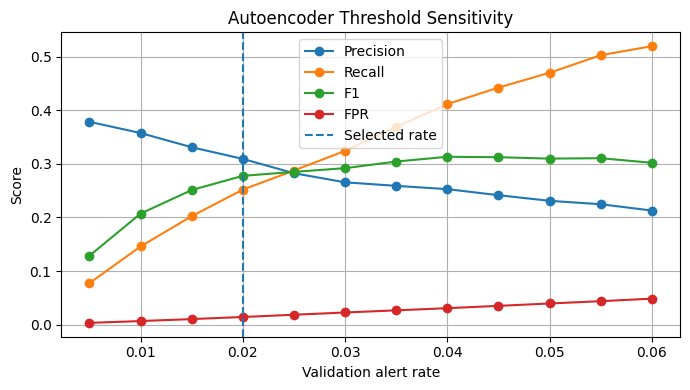

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df["alert_rate"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["alert_rate"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["alert_rate"], threshold_df["f1"], marker="o", label="F1")
plt.plot(threshold_df["alert_rate"], threshold_df["fpr"], marker="o", label="FPR")
plt.axvline(best_threshold_row["alert_rate"], linestyle="--", label="Selected rate")
plt.xlabel("Validation alert rate")
plt.ylabel("Score")
plt.title("Autoencoder Threshold Sensitivity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Results by traffic type

Classification results by traffic type:


,total,correct,incorrect,correct_rate
attack_type,,,,
Benign,40000,39415,585,98.54
DDoS-HTTP Flood,167,57,110,34.13
DoS-HTTP Flood,73,35,38,47.95
DNS Spoofing,636,131,505,20.60
Brute Force,81,15,66,18.52
XSS,52,3,49,5.77


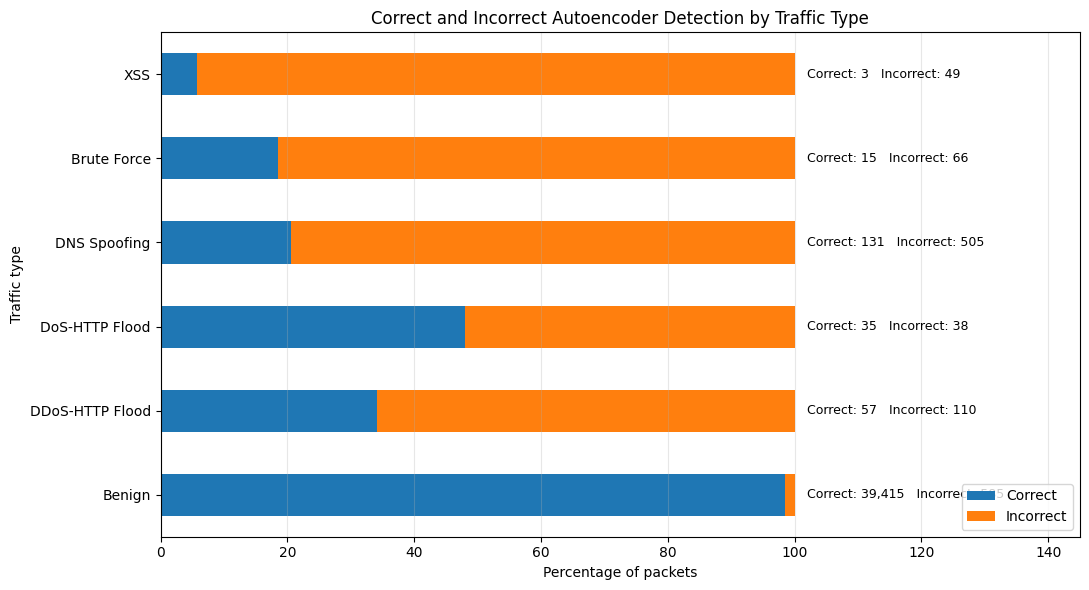

In [16]:
type_results = df_test_result[[ATTACK_COL]].copy()
type_results["y_true"] = y_test
type_results["y_pred"] = test_pred
type_results["correct"] = type_results["y_true"] == type_results["y_pred"]

result_by_type = type_results.groupby(ATTACK_COL).agg(total=("correct", "size"), correct=("correct", "sum"))
result_by_type["incorrect"] = result_by_type["total"] - result_by_type["correct"]
result_by_type["correct_rate"] = result_by_type["correct"] / result_by_type["total"] * 100
result_by_type["incorrect_rate"] = 100 - result_by_type["correct_rate"]

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
result_by_type = result_by_type.reindex(type_order).dropna()

print("Classification results by traffic type:")
display(result_by_type[["total", "correct", "incorrect", "correct_rate"]].round(2))

plot_data = result_by_type[["correct_rate", "incorrect_rate"]]
ax = plot_data.plot(kind="barh", stacked=True, figsize=(11, 6))

for i, (_, row) in enumerate(result_by_type.iterrows()):
    count_text = f'Correct: {int(row["correct"]):,}   Incorrect: {int(row["incorrect"]):,}'
    ax.text(102, i, count_text, va="center", fontsize=9)

ax.set_xlim(0, 145)
ax.set_xlabel("Percentage of packets")
ax.set_ylabel("Traffic type")
ax.set_title("Correct and Incorrect Autoencoder Detection by Traffic Type")
ax.legend(["Correct", "Incorrect"], loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

#### Confusion matrix visualization

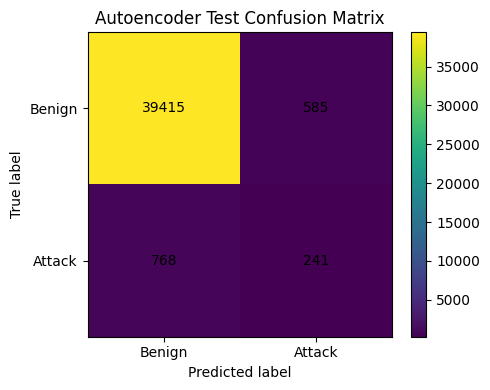

In [17]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.colorbar()
    plt.title(title)
    plt.xticks([0, 1], ["Benign", "Attack"])
    plt.yticks([0, 1], ["Benign", "Attack"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, test_pred, "Autoencoder Test Confusion Matrix")

#### ROC curve

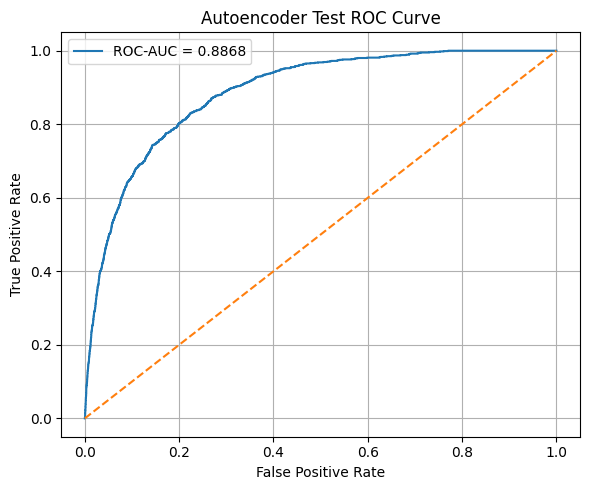

In [18]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_roc_curve(y_test, test_scores, "Autoencoder Test ROC Curve")

#### Precision-recall curve

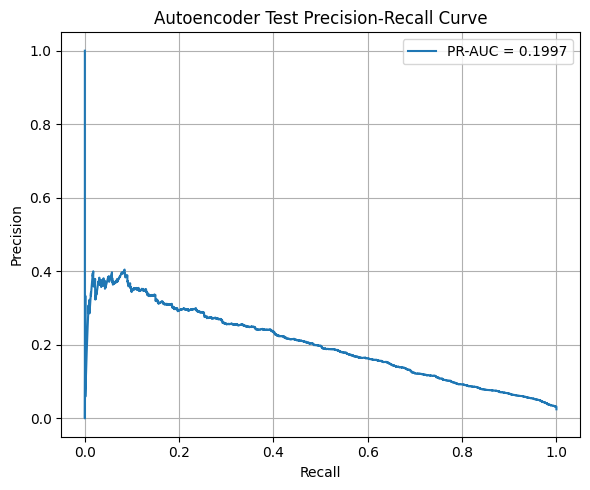

In [19]:
def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_precision_recall_curve(y_test, test_scores, "Autoencoder Test Precision-Recall Curve")

### Latent-space visualization

The encoder compresses each packet into its learned latent representation. PCA reduces those latent features to two dimensions so the true classes and generated alerts can be compared using the same plot structure as the other Phase 2 notebooks.

Explained variance: 0.4239995


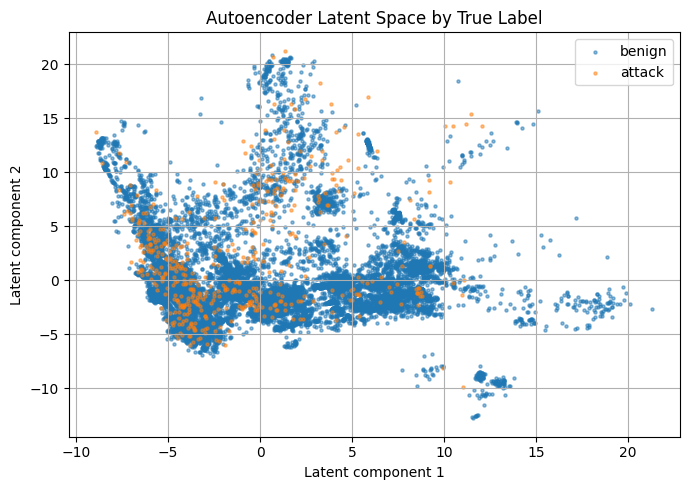

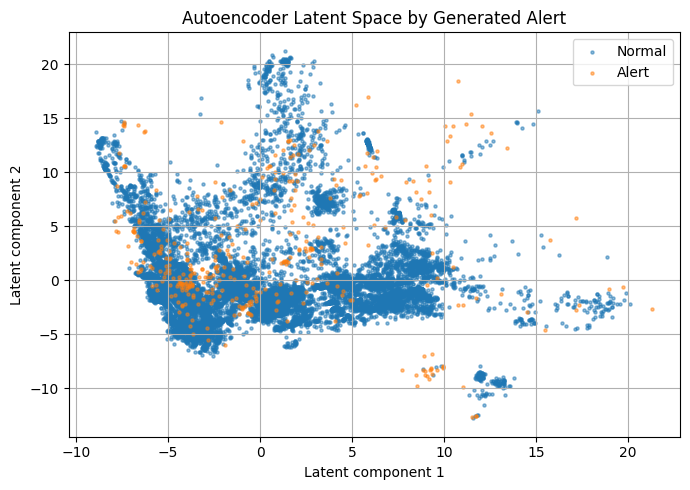

In [20]:
@torch.no_grad()
def encode_packets(model, X, batch_size=4096):
    model.eval()
    encoded = []

    for (batch,) in make_loader(X, batch_size):
        encoded.append(model.encoder(batch.to(DEVICE)).cpu().numpy())

    return np.concatenate(encoded)


plot_size = min(20000, X_test.shape[0])
rng = np.random.default_rng(1)
plot_idx = rng.choice(X_test.shape[0], size=plot_size, replace=False)
latent_test = encode_packets(autoencoder, X_test)[plot_idx]

if latent_test.shape[1] > 2:
    pca = PCA(n_components=2, random_state=1)
    latent_2d = pca.fit_transform(latent_test)
    print("Explained variance:", pca.explained_variance_ratio_.sum())
else:
    latent_2d = latent_test
    print("The bottleneck already has two dimensions.")

plot_df = pd.DataFrame({
    "Latent 1": latent_2d[:, 0],
    "Latent 2": latent_2d[:, 1],
    "binary_label": df_test_result.iloc[plot_idx][BINARY_COL].to_numpy(),
    "y_pred": df_test_result.iloc[plot_idx]["y_pred"].to_numpy(),
    "attack_type": df_test_result.iloc[plot_idx][ATTACK_COL].to_numpy()
})

plt.figure(figsize=(7, 5))
for label in ["benign", "attack"]:
    temp = plot_df[plot_df["binary_label"] == label]
    plt.scatter(temp["Latent 1"], temp["Latent 2"], s=5, alpha=0.5, label=label)
plt.xlabel("Latent component 1")
plt.ylabel("Latent component 2")
plt.title("Autoencoder Latent Space by True Label")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
for label in [0, 1]:
    temp = plot_df[plot_df["y_pred"] == label]
    name = "Normal" if label == 0 else "Alert"
    plt.scatter(temp["Latent 1"], temp["Latent 2"], s=5, alpha=0.5, label=name)
plt.xlabel("Latent component 1")
plt.ylabel("Latent component 2")
plt.title("Autoencoder Latent Space by Generated Alert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Results

In [21]:
test_row = metrics_df.iloc[0]

print("Final Autoencoder test results")
print("------------------------------")
print(f"Precision: {test_row['precision']:.4f}")
print(f"Recall: {test_row['recall']:.4f}")
print(f"F1-score: {test_row['f1']:.4f}")
print(f"ROC-AUC: {test_row['roc_auc']:.4f}")
print(f"PR-AUC: {test_row['pr_auc']:.4f}")
print(f"FPR: {test_row['fpr']:.4f}")
print(f"FNR: {test_row['fnr']:.4f}")
print(f"Test alerts: {int(test_row['alerts'])}")

print("\nDetection rate by attack type")
for attack_type in type_order[1:]:
    row = result_by_type.loc[attack_type]
    print(f"{attack_type}: {row['correct_rate']:.2f}%")

Final Autoencoder test results
------------------------------
Precision: 0.2918
Recall: 0.2389
F1-score: 0.2627
ROC-AUC: 0.8868
PR-AUC: 0.1997
FPR: 0.0146
FNR: 0.7611
Test alerts: 826

Detection rate by attack type
DDoS-HTTP Flood: 34.13%
DoS-HTTP Flood: 47.95%
DNS Spoofing: 20.60%
Brute Force: 18.52%
XSS: 5.77%


### Analysis

The autoencoder was trained without packet labels. It learned to reconstruct the dominant packet patterns, and each packet's mean squared reconstruction error was used as its anomaly score. Bottleneck size was selected using validation PR-AUC because the attack class is strongly imbalanced.

The alert threshold was selected using validation data only. Candidate thresholds were compared by F1-score while limiting the validation false-positive rate to 1.5%. The selected threshold was then frozen and applied directly to the test scores.

The final evaluation reports overall metrics and attack-specific detection rates. A high ROC-AUC with a much lower PR-AUC would indicate that the model ranks attacks above benign packets reasonably well but still has difficulty producing precise alerts under severe imbalance. The traffic-type table should be used to determine which attacks have distinctive packet-level reconstruction errors and which attacks will likely need flow-level information in Phase 3.